# Train YOLOv8 Segmentation on DeepFashion2 (Google Colab)



In [2]:
!pip install -q roboflow ultralytics opencv-python matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.7 MB/s eta 0:00:00


In [3]:
import torch
# Check if GPU is available
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU before continuing.")

GPU Available: False


## 1. Download Dataset



In [4]:
from roboflow import Roboflow

# 1. Download Dataset
# Remember to paste your API key below:
rf = Roboflow(api_key="YWQho6eOO6uTFLJ3hsGQ")
project = rf.workspace("labsni").project("deepfashion2-bfwof-0y8xr")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DeepFashion2-1 in yolov8:: 100%|██████████| 1644/1644 [00:00<00:00, 3339.86it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Data Exploration & Analysis (EDA)



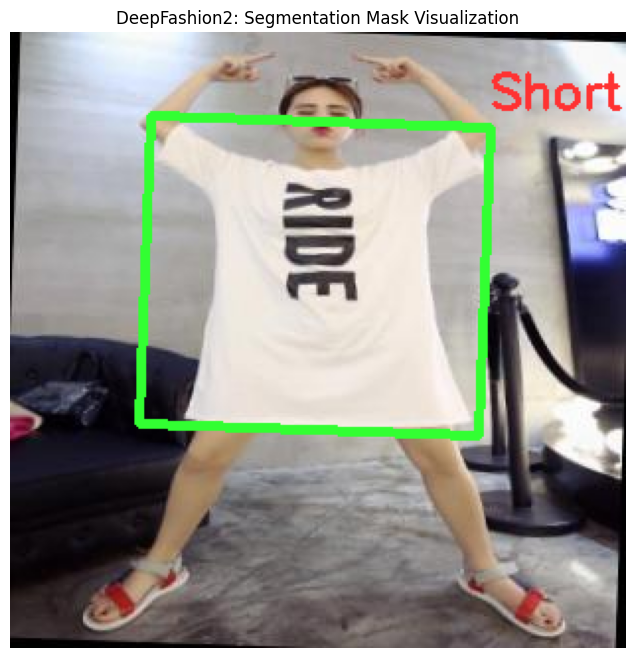


Dataset contains 3 classes including: Long Sleeve top, Short Sleeve top, Shorts...


In [5]:
import yaml
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import glob

# Load class names from the YAML config
with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_info = yaml.safe_load(f)
classes = data_info.get('names', [])
if isinstance(classes, dict):
    classes = [classes[i] for i in range(len(classes))]

# Pick a random image
train_imgs = glob.glob(f"{dataset.location}/train/images/*.jpg")
if train_imgs:
    sample_img_path = random.choice(train_imgs)
    base_name = os.path.basename(sample_img_path).replace('.jpg', '.txt')
    sample_label_path = os.path.join(dataset.location, "train/labels", base_name)

    img = cv2.imread(sample_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Draw the polygons if a label file exists
    if os.path.exists(sample_label_path):
        with open(sample_label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) > 1:
                    cls_id = int(parts[0])
                    coords = [float(x) for x in parts[1:]]

                    # Convert normalized coords back to absolute pixels
                    points = []
                    for i in range(0, len(coords), 2):
                        points.append([int(coords[i] * w), int(coords[i+1] * h)])
                    points = np.array(points, np.int32).reshape((-1, 1, 2))

                    # Draw outline and label
                    cv2.polylines(img, [points], isClosed=True, color=(50, 255, 50), thickness=3)
                    class_name = classes[cls_id] if cls_id < len(classes) else str(cls_id)
                    cv2.putText(img, class_name, (points[0][0][0], points[0][0][1] - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 50, 50), 2)

    # Render visualization
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("DeepFashion2: Segmentation Mask Visualization")
    plt.show()
    print(f"\nDataset contains {len(classes)} classes including: {', '.join(classes[:5])}...")
else:
    print("Could not find images for EDA.")

## 3. Train the Model


In [6]:
from ultralytics import YOLO

# Load the Pre-trained YOLOv8 Segmentation Model (medium model)
model = YOLO('yolov8m-seg.pt')

# Train the Model
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,      # YOLO stops early if it plateaus, so 100 is safe
    imgsz=640,       # High resolution for DeepFashion2
    batch=16,        # Fits into VRAM of a Colab T4 GPU
    device=0,        # Train on GPU 0
    project='runs_outfit_ai',
    name='train_run'
)

KeyboardInterrupt: 

In [7]:
best_model = YOLO('/content/best (10).pt')
metrics = best_model.val()

print("\n=== Segmentation metrics (mask) ===")
print(f"mAP50: {metrics.seg.map50:.3f}")
print(f"mAP50-95: {metrics.seg.map:.3f}")
print("\nThese are the numbers that actually tell you whether the model is good — "
      "not the training loss curve. mAP50-95 in the 0.4-0.6 range is a reasonable, "
      "realistic result for this kind of task; don't expect 0.9+.")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8m-seg summary (fused): 106 layers, 27,224,121 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 568.4±357.2 MB/s, size: 14.5 KB)
val: Scanning /content/DeepFashion2-1/valid/labels... 68 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 1.8Kit/s 0.0s
val: New cache created: /content/DeepFashion2-1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 37.8s/it 3:09
                   all         68         78      0.805      0.873      0.893      0.692      0.805      0.873      0.893      0.675
       Long Sleeve top         16         16      0.713      0.776      0.784      0.533      0.713      0.776      0.784      0.526
      Short Sleeve top         44         44      0.876      0.955      0.976       0.75      0.876      0.955 

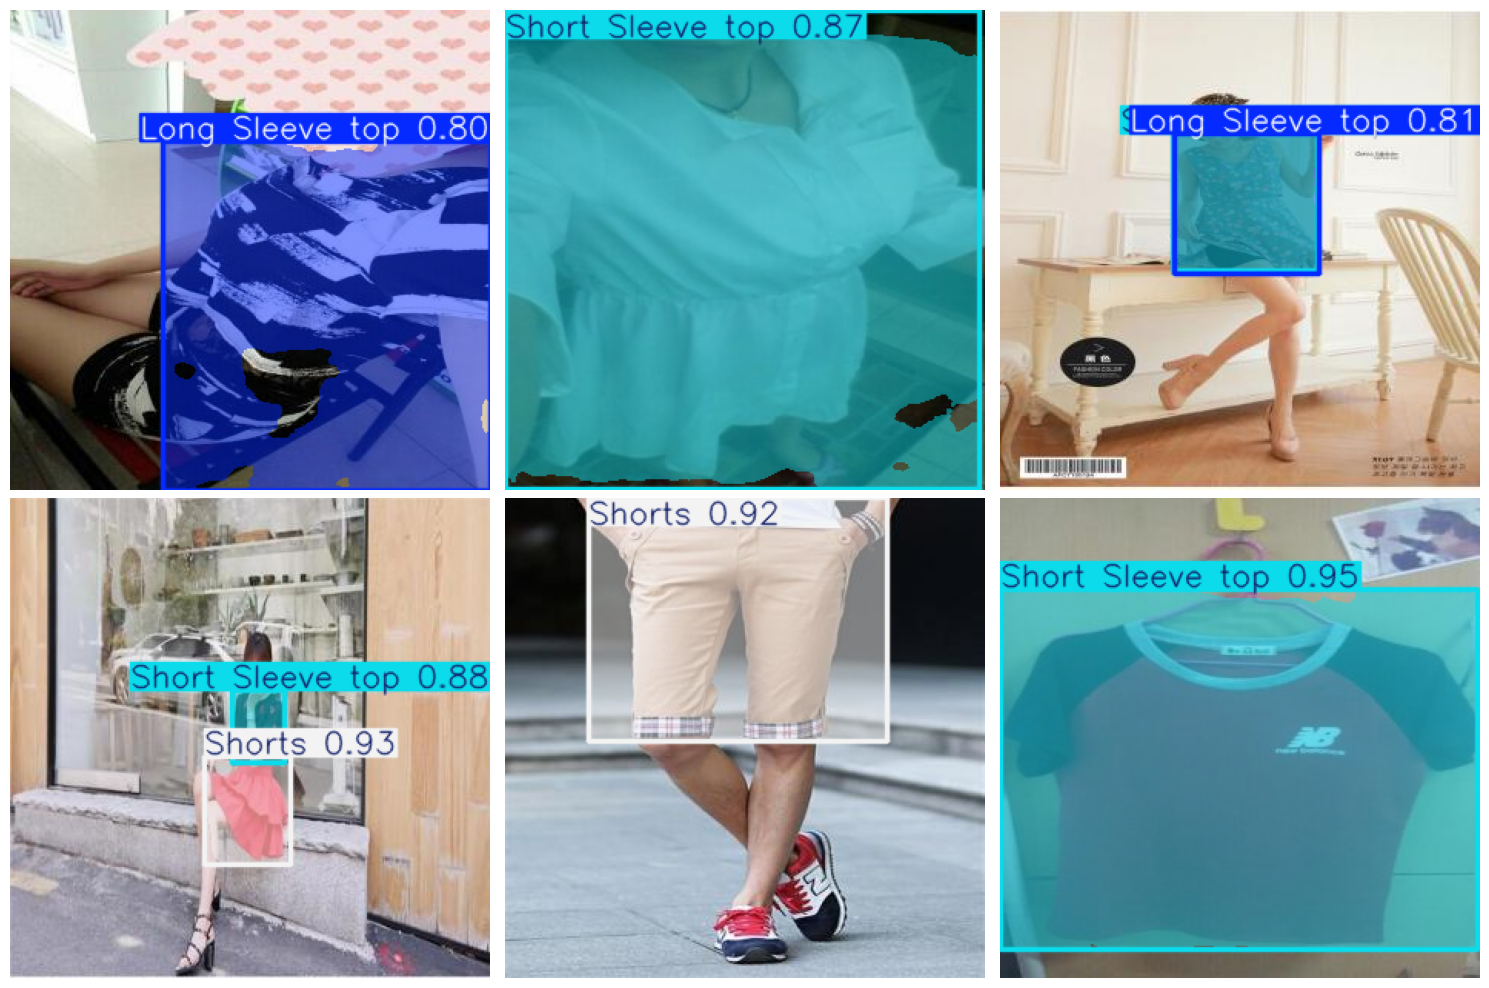

In [10]:
# Visual sanity check on a few validation images
val_imgs = glob.glob(f"{dataset.location}/valid/images/*.jpg")[:6]
if val_imgs:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, img_path in zip(axes.flat, val_imgs):
        pred = best_model.predict(img_path, conf=0.4, verbose=False)[0]
        annotated = pred.plot()
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No validation images found for visual check.")

Saving Black.webp to Black.webp

image 1/1 /content/Black.webp: 640x576 1 Short Sleeve top, 61.9ms
Speed: 2.9ms preprocess, 61.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 576)


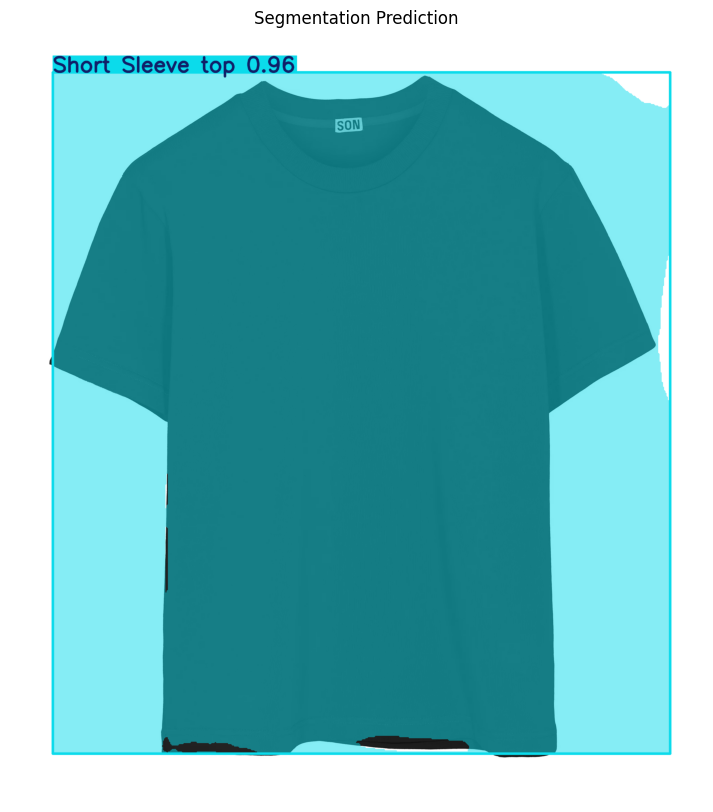

Short Sleeve top: 0.96


In [10]:
from google.colab import files
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Load the trained model (adjust path if you renamed/moved the weights file)
trained_model = YOLO('runs/segment/runs_outfit_ai/train_run/weights/best.pt')
# Upload an image from your computer
uploaded = files.upload()
image_path = next(iter(uploaded))  # grabs the filename of the uploaded file

# Run inference
results = trained_model.predict(source=image_path, conf=0.25, save=False)

# Plot the result (draws boxes + segmentation masks + labels)
result_img = results[0].plot()  # returns a BGR numpy array
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(result_img_rgb)
plt.axis('off')
plt.title('Segmentation Prediction')
plt.show()

# Print detected classes and confidence scores
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    cls_name = trained_model.names[cls_id]
    print(f"{cls_name}: {conf:.2f}")

## 4. Download Model Weights
Once training finishes, run this cell to download your new `.pt` file, which you will place in the API's `weights/` directory.

In [6]:
from google.colab import files
files.download('runs_outfit_ai/train_run/weights/best.pt')

FileNotFoundError: Cannot find file: runs_outfit_ai/train_run/weights/best.pt